# 成员A 模块联调 Demo（调试/演示用）
## image_loader + image_feature + data_augmentation 组合调用示例

> **本 notebook 使用少量数据（max_train=500~1000）快速演示 API 调用。**
> **正式训练时请去掉 max_train/max_test 参数，加载全量数据。**

> **首次运行**：torchvision 自动下载 MNIST (~50MB) + EMNIST-letters (~560MB) 到 `./data/` 目录，后续直接读缓存。
> **本演示**：为快速跑通流程，用 `max_train`/`max_test` 限制加载量；正式训练时去掉这两个参数即可。

## 1. 数据加载 —— 两种方式任选

In [1]:
from image_loader import load_torchvision_data, get_dataset, preprocess_single
from image_loader import split_dataset

### 方式一（★推荐）：torchvision 自动加载
首次运行自动下载，后续直接读缓存。

In [2]:
digits = load_torchvision_data('mnist', max_train=1000, max_test=500, verbose=False)
print('数字数据集:')
print(f'  训练: {digits["X_train"].shape}, 标签: {digits["y_train"].shape}')
print(f'  验证: {digits["X_val"].shape},   标签: {digits["y_val"].shape}')
print(f'  测试: {digits["X_test"].shape},  标签: {digits["y_test"].shape}')
print(f'  类别: {digits["classes"]}')

数字数据集:
  训练: (749, 28, 28), 标签: (749,)
  验证: (251, 28, 28),   标签: (251,)
  测试: (500, 28, 28),  标签: (500,)
  类别: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


In [3]:
letters = load_torchvision_data('letters', max_train=1000, max_test=500, verbose=False)
print('字母数据集:')
print(f'  训练: {letters["X_train"].shape}, 标签: {letters["y_train"].shape}')
print(f'  验证: {letters["X_val"].shape},   标签: {letters["y_val"].shape}')
print(f'  测试: {letters["X_test"].shape},  标签: {letters["y_test"].shape}')
print(f'  类别: {letters["classes"]}')

字母数据集:
  训练: (749, 28, 28), 标签: (749,)
  验证: (251, 28, 28),   标签: (251,)
  测试: (500, 28, 28),  标签: (500,)
  类别: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


### 方式二：通过 get_dataset() 统一接口（同时加载数字+字母）

In [4]:
datasets = get_dataset({
    'use_torchvision': True,
    'torchvision_datasets': ['mnist', 'letters'],
    'torchvision_kwargs': {'max_train': 500, 'max_test': 200},
})

for key in ['digits', 'letters']:
    if key in datasets:
        d = datasets[key]
        print(f'{key}: 训练 {d["X_train"].shape} / 验证 {d["X_val"].shape} / 测试 {d["X_test"].shape}')

[image_loader] 通过 torchvision 加载 MNIST 手写数字数据集...
  加载训练集 (500 / 60000 张)...
  加载测试集 (200 / 10000 张)...
  预处理训练集 (500 张)...
  预处理测试集 (200 张)...
  完成: 训练 374 / 验证 126 / 测试 200
[image_loader] 通过 torchvision 加载 EMNIST-letters 手写字母数据集...
  加载训练集 (500 / 124800 张)...
  加载测试集 (200 / 20800 张)...
  校正 EMNIST 图像方向...
  预处理训练集 (500 张)...
  预处理测试集 (200 张)...
  完成: 训练 374 / 验证 126 / 测试 200
digits: 训练 (374, 28, 28) / 验证 (126, 28, 28) / 测试 (200, 28, 28)
letters: 训练 (374, 28, 28) / 验证 (126, 28, 28) / 测试 (200, 28, 28)


### 附：preprocess_single —— 单张图像预处理（GUI 画板用）

成员C在GUI中拿到用户手写图片后，调用此函数完成预处理。

原始尺寸: (28, 28)
预处理后: (28, 28)  二值图: (28, 28)


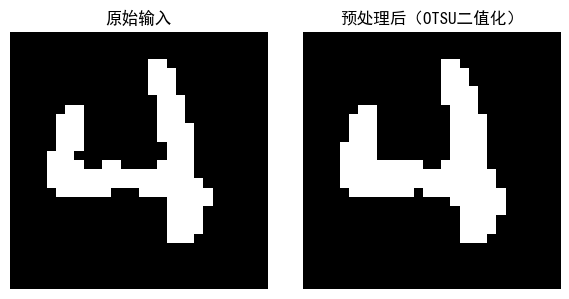

In [6]:
# 模拟 GUI 画板传来的用户手写输入
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']  # 或 'Microsoft YaHei', 'KaiTi' 等
plt.rcParams['axes.unicode_minus'] = False   # 解决负号显示异常
raw_img = digits['X_train'][0]  # (28,28) uint8, 模拟画板原始输入

# 调用预处理 — 成员C在GUI中拿到图片后调用此函数
preprocessed, binary = preprocess_single(raw_img, target_size=28)

print(f'原始尺寸: {raw_img.shape}')
print(f'预处理后: {preprocessed.shape}  二值图: {binary.shape}')

# 对比显示
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(raw_img, cmap='gray'); axes[0].set_title('原始输入')
axes[0].axis('off')
axes[1].imshow(preprocessed, cmap='gray'); axes[1].set_title('预处理后（OTSU二值化）')
axes[1].axis('off')
plt.tight_layout(); plt.show()

### 附：load_prepared_data —— 备选方案（离线 .npz 加载）

仅当已运行过 `python prepare_data.py` 生成 .npz 文件后才可用。
网络受限时可替代 torchvision 方式。

In [7]:
from image_loader import load_prepared_data

try:
    digits_npz = load_prepared_data('mnist')
    print('MNIST .npz 加载成功')
    print(f'  训练: {digits_npz["X_train"].shape}')
except FileNotFoundError as e:
    print(f'(预期报错) {e}')
    print('-> 请改用 load_torchvision_data("mnist") 或先运行 python prepare_data.py')

MNIST .npz 加载成功
  训练: (44999, 28, 28)


## 2. 可视化几张样本

In [8]:
import matplotlib.pyplot as plt
import numpy as np

def show_samples(X, y, classes, title='', rows=2, cols=5):
    fig, axes = plt.subplots(rows, cols, figsize=(cols*2, rows*2))
    for i, ax in enumerate(axes.flat):
        idx = np.random.randint(0, len(X))
        ax.imshow(X[idx], cmap='gray')
        ax.set_title(f'{classes[y[idx]]}', fontsize=10)
        ax.axis('off')
    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

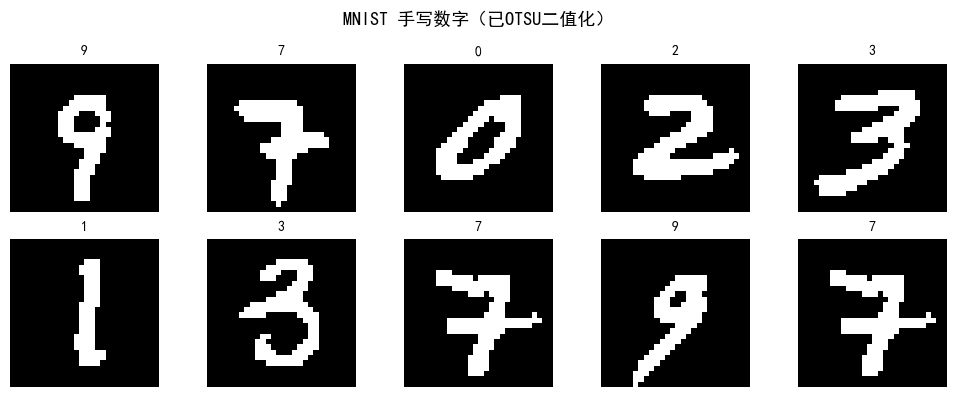

In [9]:
show_samples(digits['X_train'], digits['y_train'], digits['classes'], 'MNIST 手写数字（已OTSU二值化）')

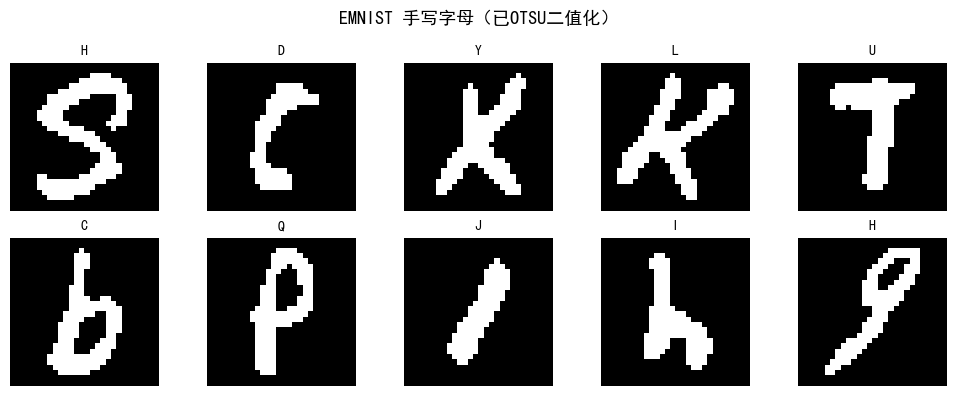

In [10]:
show_samples(letters['X_train'], letters['y_train'], letters['classes'], 'EMNIST 手写字母（已OTSU二值化）')

## 3. 数据增强

In [11]:
from data_augmentation import augment_dataset, augment_single

# 取小批量演示
X_small = digits['X_train'][:100]
y_small = digits['y_train'][:100]

X_aug, y_aug = augment_dataset(X_small, y_small, factor=3, random_seed=42)
print(f'增强前: {X_small.shape}')
print(f'增强后: {X_aug.shape}  (factor=3)')

增强前: (100, 28, 28)
增强后: (300, 28, 28)  (factor=3)


### 对比：原图 vs 增强版

In [12]:
def show_aug_comparison(original, aug_all, labels, factor, num_examples=5):
    N = len(original)
    fig, axes = plt.subplots(num_examples, factor, figsize=(factor*2.5, num_examples*2.2))
    for row in range(num_examples):
        idx = np.random.randint(0, N)
        # 第一列：原图
        axes[row, 0].imshow(original[idx], cmap='gray')
        axes[row, 0].set_title(f'原图 ({labels[idx]})', fontsize=9)
        axes[row, 0].axis('off')
        # 后续列：增强版本
        for col in range(1, factor):
            aug_idx = (col - 1) * N + idx
            axes[row, col].imshow(aug_all[aug_idx], cmap='gray')
            axes[row, col].set_title(f'增强{col}', fontsize=9)
            axes[row, col].axis('off')
    plt.tight_layout()
    plt.show()

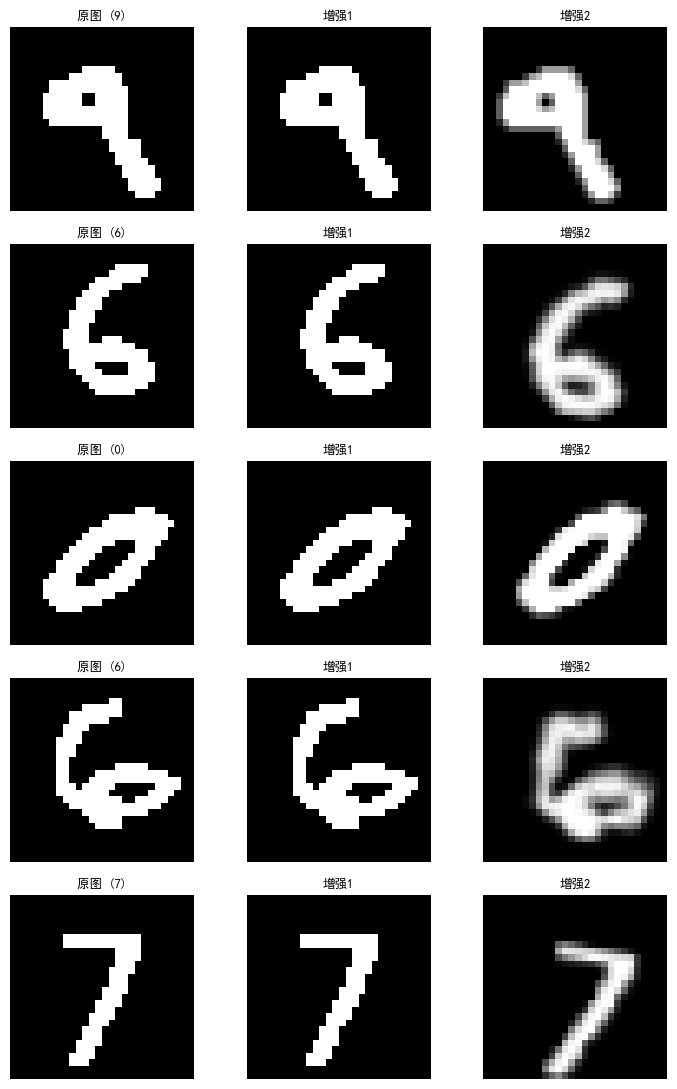

In [13]:
show_aug_comparison(X_small, X_aug, y_small, factor=3)

### 单张随机增强（GUI 实时识别测试用）

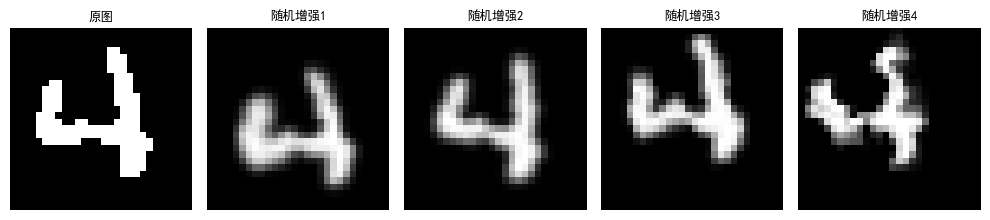

In [14]:
single_img = digits['X_train'][0]
fig, axes = plt.subplots(1, 5, figsize=(10, 2.2))
axes[0].imshow(single_img, cmap='gray')
axes[0].set_title('原图', fontsize=9); axes[0].axis('off')

for i in range(1, 5):
    aug = augment_single(single_img, rng=np.random.RandomState(i))
    axes[i].imshow(aug, cmap='gray')
    axes[i].set_title(f'随机增强{i}', fontsize=9)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

## 4. 特征提取 —— 三种方法

In [15]:
from image_feature import extract_features, get_feature_dim, get_all_methods

print('支持的特征提取方法:', get_all_methods())

支持的特征提取方法: ['pixel', 'projection', 'structure']


### 4.1 维度一览

In [16]:
for method in get_all_methods():
    dim = get_feature_dim(method, image_size=28, grid_size=28)
    print(f'  {method:12s} → {dim:4d} 维')

  pixel        →  784 维
  projection   →   56 维
  structure    →   17 维


### 4.1 附：pixel 特征的 grid_size=14 变体（196维）

通过 `grid_size=14` 可将像素特征从 784 维降至 196 维，减少 BP 网络计算量。

In [17]:
# grid_size=28 -> 784维  vs  grid_size=14 -> 196维
F_pixel_28 = extract_features(digits['X_train'][:1000], method='pixel', grid_size=28)
F_pixel_14 = extract_features(digits['X_train'][:1000], method='pixel', grid_size=14)

print(f'grid_size=28: {F_pixel_28.shape}  (784维)')
print(f'grid_size=14: {F_pixel_14.shape}  (196维)')
print(f'维度缩减: {(1 - 196/784)*100:.0f}%')

grid_size=28: (749, 784)  (784维)
grid_size=14: (749, 196)  (196维)
维度缩减: 75%


### 4.2 对数字数据集提取三种特征

In [18]:
X = digits['X_train']

F_pixel = extract_features(X, method='pixel', grid_size=28)
F_proj  = extract_features(X, method='projection')
F_struc = extract_features(X, method='structure')

print('数字数据集特征矩阵:')
print(f'  pixel       → {F_pixel.shape}')
print(f'  projection  → {F_proj.shape}')
print(f'  structure   → {F_struc.shape}')

数字数据集特征矩阵:
  pixel       → (749, 784)
  projection  → (749, 56)
  structure   → (749, 17)


### 4.3 对字母数据集提取三种特征

In [19]:
X_let = letters['X_train']

F_pixel_l = extract_features(X_let, method='pixel', grid_size=28)
F_proj_l  = extract_features(X_let, method='projection')
F_struc_l = extract_features(X_let, method='structure')

print('字母数据集特征矩阵:')
print(f'  pixel       → {F_pixel_l.shape}')
print(f'  projection  → {F_proj_l.shape}')
print(f'  structure   → {F_struc_l.shape}')

字母数据集特征矩阵:
  pixel       → (749, 784)
  projection  → (749, 56)
  structure   → (749, 17)


### 4.4 可视化：投影特征

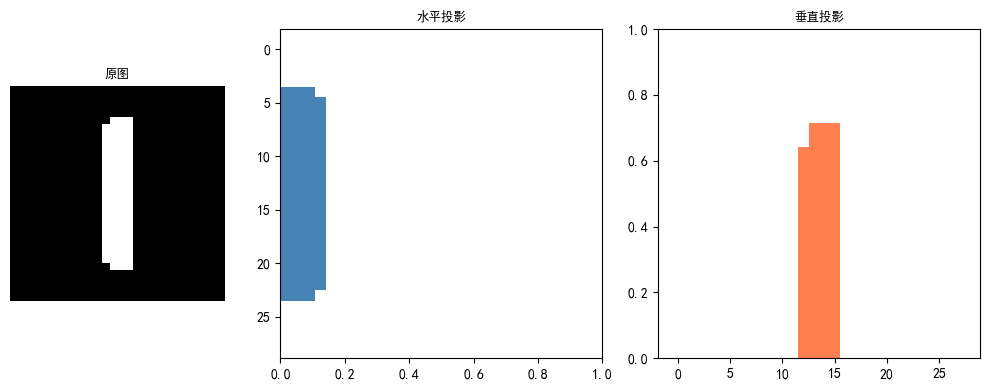

In [20]:
def visualize_projection(img, ax_img, ax_h, ax_v):
    """可视化原图 + 水平投影 + 垂直投影"""
    H, W = img.shape
    h_proj = np.sum(img.astype(np.float32), axis=1) / (W * 255)
    v_proj = np.sum(img.astype(np.float32), axis=0) / (H * 255)

    ax_img.imshow(img, cmap='gray')
    ax_img.set_title('原图', fontsize=9); ax_img.axis('off')

    ax_h.barh(np.arange(H), h_proj, height=1, color='steelblue')
    ax_h.invert_yaxis()
    ax_h.set_title('水平投影', fontsize=9); ax_h.set_xlim(0, 1)

    ax_v.bar(np.arange(W), v_proj, width=1, color='coral')
    ax_v.set_title('垂直投影', fontsize=9); ax_v.set_ylim(0, 1)


idx = np.random.randint(0, len(X))
fig, axes = plt.subplots(1, 3, figsize=(10, 4),
                         gridspec_kw={'width_ratios': [1, 1.5, 1.5]})
visualize_projection(X[idx], axes[0], axes[1], axes[2])
plt.tight_layout()
plt.show()

### 4.5 可视化：结构特征中的笔画穿越线

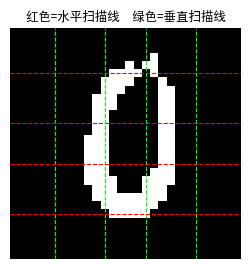

In [21]:
def draw_stroke_lines(img, num_lines=4):
    """在原图上画出笔画穿越扫描线"""
    H, W = img.shape
    fig, ax = plt.subplots(figsize=(3, 3))
    ax.imshow(img, cmap='gray')
    for i in range(1, num_lines + 1):
        y = int(i * H / (num_lines + 1))
        ax.axhline(y, color='red', linewidth=0.8, linestyle='--')
        x = int(i * W / (num_lines + 1))
        ax.axvline(x, color='lime', linewidth=0.8, linestyle='--')
    ax.set_title('红色=水平扫描线  绿色=垂直扫描线', fontsize=9)
    ax.axis('off')
    plt.show()

draw_stroke_lines(digits['X_train'][np.random.randint(0, len(X))])

## 5. 完整联调流程（给成员B的接口入参示范）

In [22]:
from image_loader import load_torchvision_data
from image_feature import extract_features, get_feature_dim
from data_augmentation import augment_dataset

# ===== 配置 =====
METHOD = 'pixel'       # 特征方法: 'pixel' | 'projection' | 'structure'
AUG_FACTOR = 2         # 增强倍数（演示用小一点，正式训练用 3~5）
IMAGE_SIZE = 28

# ===== Step 1: 加载数据 =====
print('=' * 50)
print('Step 1: 加载数据集（演示模式：少量数据）')
print('=' * 50)
# 正式训练请去掉 max_train/max_test，改为：
# digits = load_torchvision_data('mnist')
digits = load_torchvision_data('mnist', max_train=500, max_test=200, verbose=False)

# ===== Step 2: 数据增强 =====
print('\n' + '=' * 50)
print('Step 2: 数据增强')
print('=' * 50)
# 正式训练建议 factor=3~5
X_aug, y_aug = augment_dataset(digits['X_train'], digits['y_train'],
                               factor=AUG_FACTOR, random_seed=42)
print(f'  训练集: {digits["X_train"].shape[0]} → {X_aug.shape[0]} (×{AUG_FACTOR})')

# ===== Step 3: 特征提取 =====
print('\n' + '=' * 50)
print('Step 3: 特征提取')
print('=' * 50)
F_train = extract_features(X_aug,              method=METHOD)
F_val   = extract_features(digits['X_val'],   method=METHOD)
F_test  = extract_features(digits['X_test'],  method=METHOD)
print(f'  方法: {METHOD}')
print(f'  F_train: {F_train.shape}')
print(f'  F_val:   {F_val.shape}')
print(f'  F_test:  {F_test.shape}')

# ===== Step 4: 传给成员B =====
print('\n' + '=' * 50)
print('Step 4: BP网络参数')
print('=' * 50)
input_dim  = get_feature_dim(METHOD, image_size=IMAGE_SIZE)
output_dim = len(digits['classes'])

print(f'  input_dim  = {input_dim}   # 成员B: BP.__init__(input_dim={input_dim}, ...)')
print(f'  output_dim = {output_dim}  # 成员B: BP.__init__(..., output_dim={output_dim})')
print(f'  F_train → 成员B: model.train(F_train, y_aug, F_val, y_val)')
print(f'  F_test  → 成员B: model.evaluate(F_test, y_test)')

print()
print('=' * 50)
print('!! 正式训练时：去掉 max_train/max_test，factor 改为 3~5 !!')
print('=' * 50)

Step 1: 加载数据集（演示模式：少量数据）

Step 2: 数据增强
  训练集: 374 → 748 (×2)

Step 3: 特征提取
  方法: pixel
  F_train: (748, 784)
  F_val:   (126, 784)
  F_test:  (200, 784)

Step 4: BP网络参数
  input_dim  = 784   # 成员B: BP.__init__(input_dim=784, ...)
  output_dim = 10  # 成员B: BP.__init__(..., output_dim=10)
  F_train → 成员B: model.train(F_train, y_aug, F_val, y_val)
  F_test  → 成员B: model.evaluate(F_test, y_test)

!! 正式训练时：去掉 max_train/max_test，factor 改为 3~5 !!
